# 02 — Exploratory Data Analysis

**Owner:** Seneviratne's lane — distributions, outliers, correlations, class-conditional comparisons, `grip_lost` analysis.

Viva questions to be ready for: Are outliers errors or signal? Which features separate the classes?

Remember: every important choice gets a decision-log cell below it (what we decided, evidence, alternative considered, why rejected).

In [1]:
import sys
from pathlib import Path

# Jupyter's kernel CWD is notebooks/, so add the repo root to sys.path
# before importing anything from src/.
sys.path.append(str(Path.cwd().parent))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RANDOM_STATE, FIGURES_DIR
from src.pipeline import load_data

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
df = load_data()
df.shape

(7409, 24)

## Sensor families

Group columns by family for reuse below (Current_*, Temperature_*, Speed_J*, Tool_current).

In [4]:
current_cols = [c for c in df.columns if c.startswith("Current_")]
temperature_cols = [c for c in df.columns if c.startswith("Temperature_")]
speed_cols = [c for c in df.columns if c.startswith("Speed_")]
tool_cols = ["Tool_current"]

current_cols, temperature_cols, speed_cols, tool_cols

(['Current_J0',
  'Current_J1',
  'Current_J2',
  'Current_J3',
  'Current_J4',
  'Current_J5'],
 ['Temperature_T0',
  'Temperature_J1',
  'Temperature_J2',
  'Temperature_J3',
  'Temperature_J4',
  'Temperature_J5'],
 ['Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5'],
 ['Tool_current'])

## Distributions by sensor family and class

Histogram and KDE plots per feature split by `Robot_ProtectiveStop` (0 vs 1) and grouped by sensor family. Figures are saved to `FIGURES_DIR / "fig02_distributions_<family>.png"`.

Saved: C:\FDM_Mini_Project\UR3-CobotOps-Fault-Detection\reports\figures\fig02_distributions_current.png


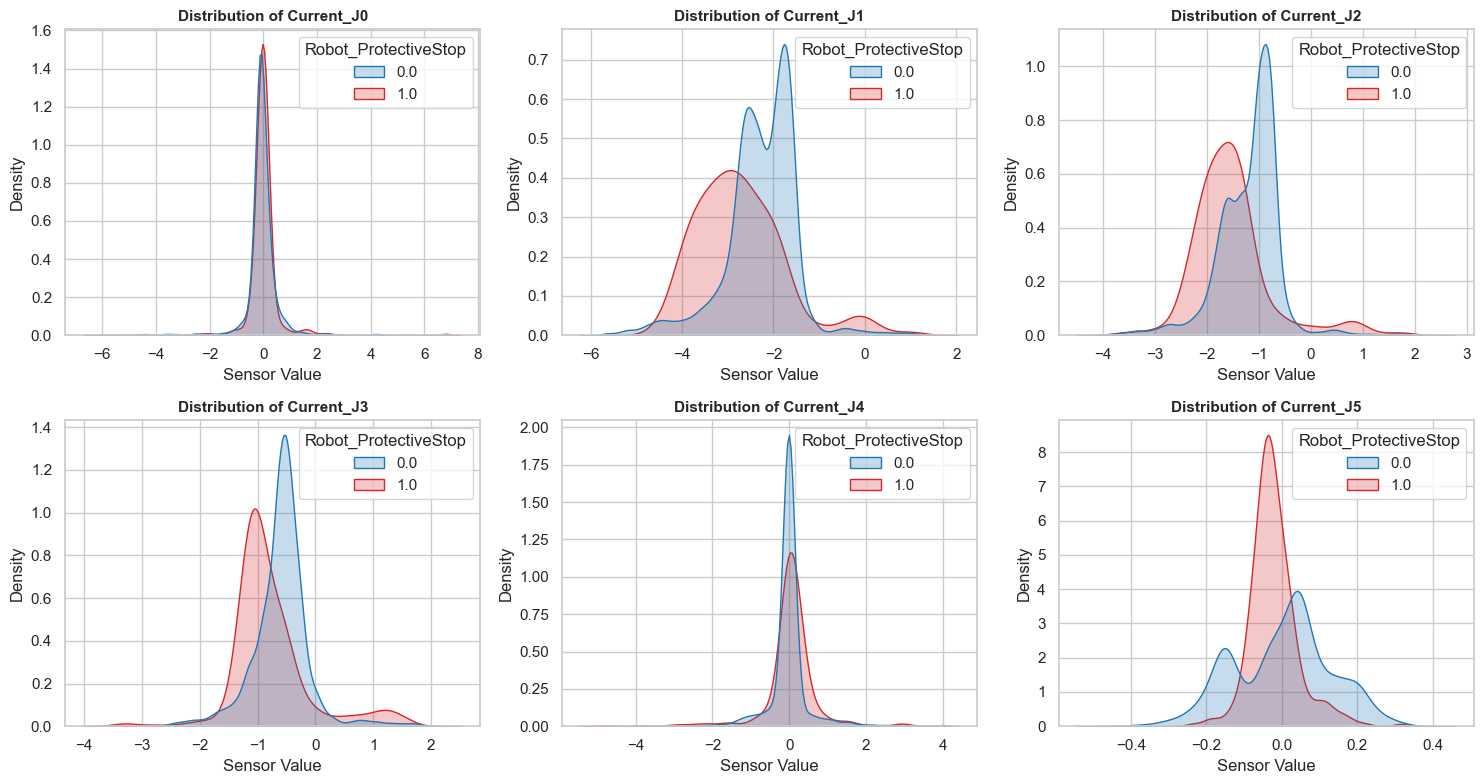

Saved: C:\FDM_Mini_Project\UR3-CobotOps-Fault-Detection\reports\figures\fig02_distributions_temperature.png


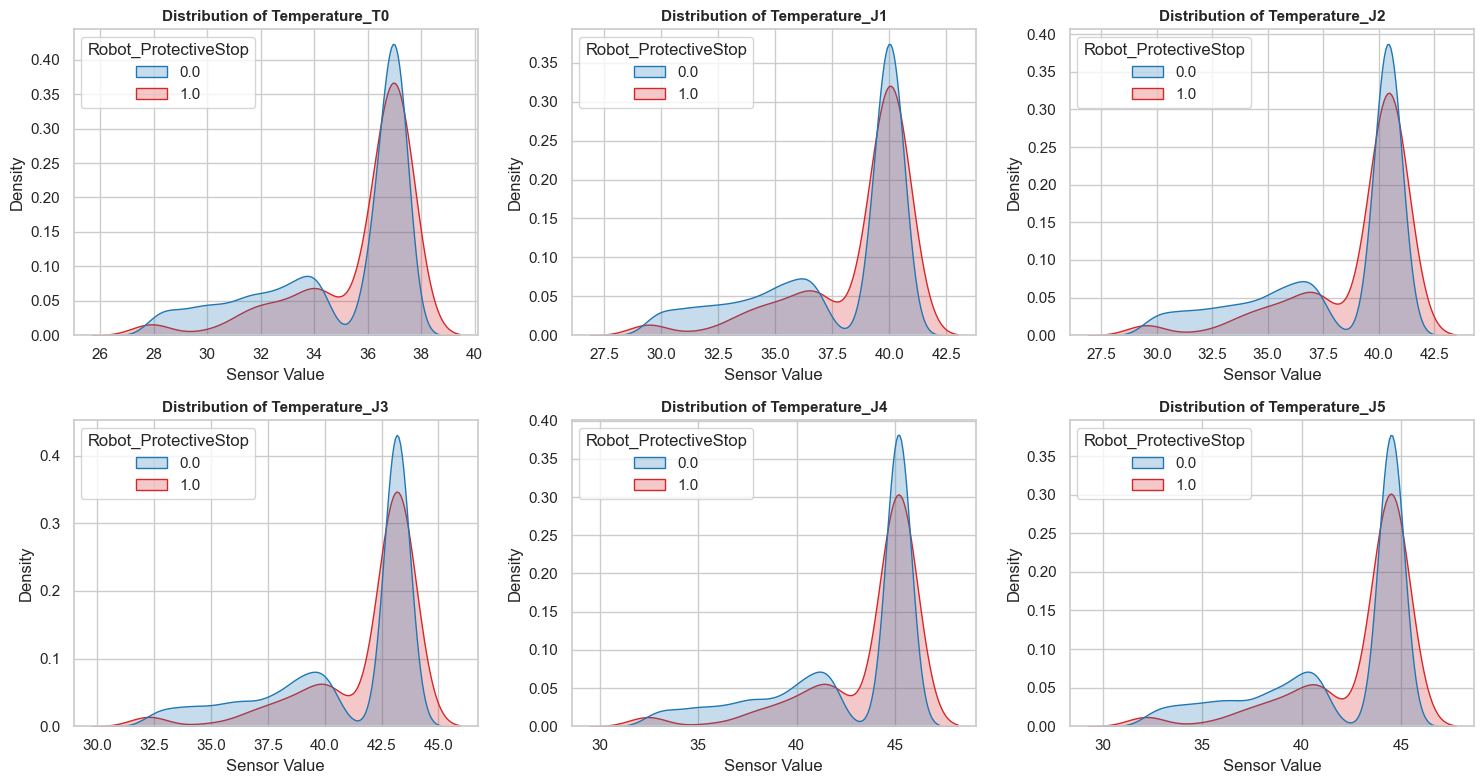

Saved: C:\FDM_Mini_Project\UR3-CobotOps-Fault-Detection\reports\figures\fig02_distributions_speed.png


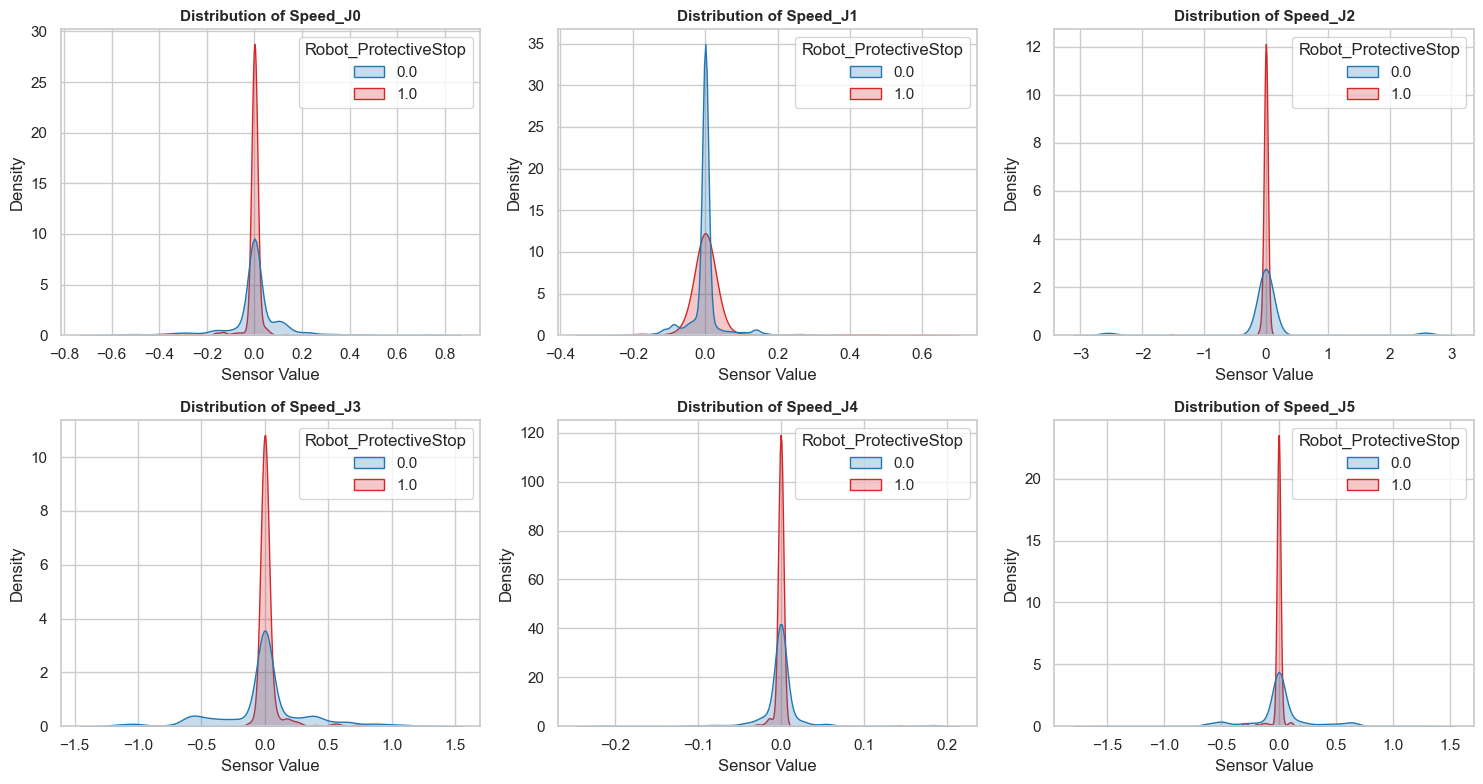

Saved: C:\FDM_Mini_Project\UR3-CobotOps-Fault-Detection\reports\figures\fig02_distributions_tool.png


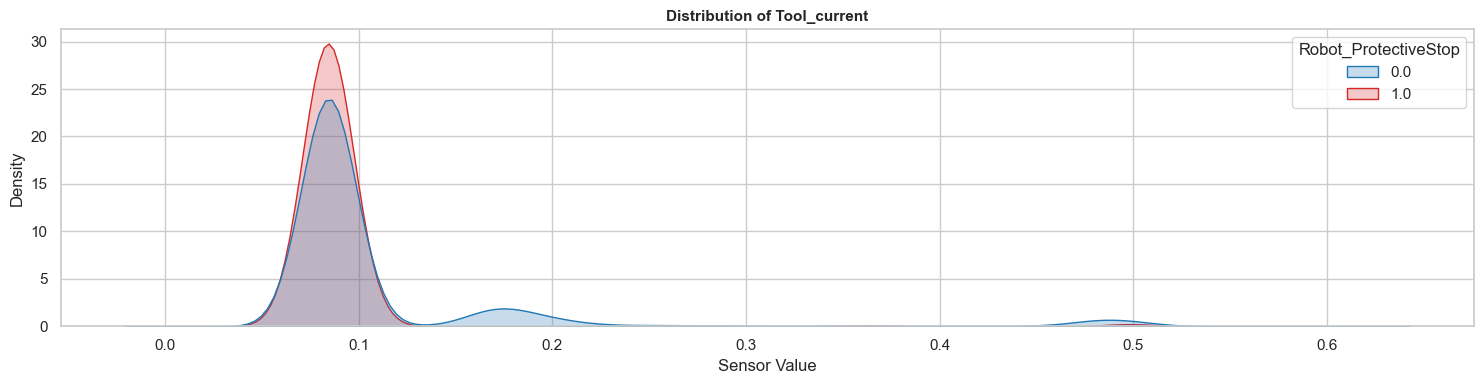

In [5]:
# Distributions per sensor family split by class
families = {
    "current": current_cols,
    "temperature": temperature_cols,
    "speed": speed_cols,
    "tool": tool_cols
}

for family_name, cols in families.items():
    n_cols = len(cols)
    fig, axes = plt.subplots(nrows=(n_cols + 2) // 3, ncols=min(3, n_cols), figsize=(15, 4 * ((n_cols + 2) // 3)))
    if n_cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for idx, col in enumerate(cols):
        sns.kdeplot(
            data=df,
            x=col,
            hue="Robot_ProtectiveStop",
            common_norm=False,
            fill=True,
            palette={0: "#1f77b4", 1: "#d62728"},
            ax=axes[idx]
        )
        axes[idx].set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
        axes[idx].set_xlabel("Sensor Value")
    
    for idx in range(n_cols, len(axes)):
        fig.delaxes(axes[idx])
        
    plt.tight_layout()
    fig_path = FIGURES_DIR / f"fig02_distributions_{family_name}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {fig_path}")
    plt.show()

## Boxplots + outlier counts

Boxplot per feature; count IQR-based outliers per feature (below Q1 - 1.5*IQR or above Q3 + 1.5*IQR). Decide per-feature whether outliers look like sensor errors or genuine extreme readings (part of the viva answer).

In [6]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

numeric_cols = current_cols + temperature_cols + speed_cols + tool_cols
outlier_summary = pd.DataFrame({
    "outlier_count": [iqr_outlier_count(df[c]) for c in numeric_cols],
    "outlier_pct": [round(100 * iqr_outlier_count(df[c]) / len(df), 2) for c in numeric_cols]
}, index=numeric_cols)

outlier_summary.sort_values(by="outlier_count", ascending=False)

,outlier_count,outlier_pct
Speed_J3,3432,46.32
Speed_J0,3215,43.39
Speed_J4,3172,42.81
Speed_J5,3164,42.70
Speed_J1,2962,39.98
Speed_J2,2715,36.64
Current_J4,1313,17.72
Tool_current,1043,14.08
Current_J0,967,13.05
Current_J3,579,7.81


Saved: C:\FDM_Mini_Project\UR3-CobotOps-Fault-Detection\reports\figures\fig02_boxplots.png


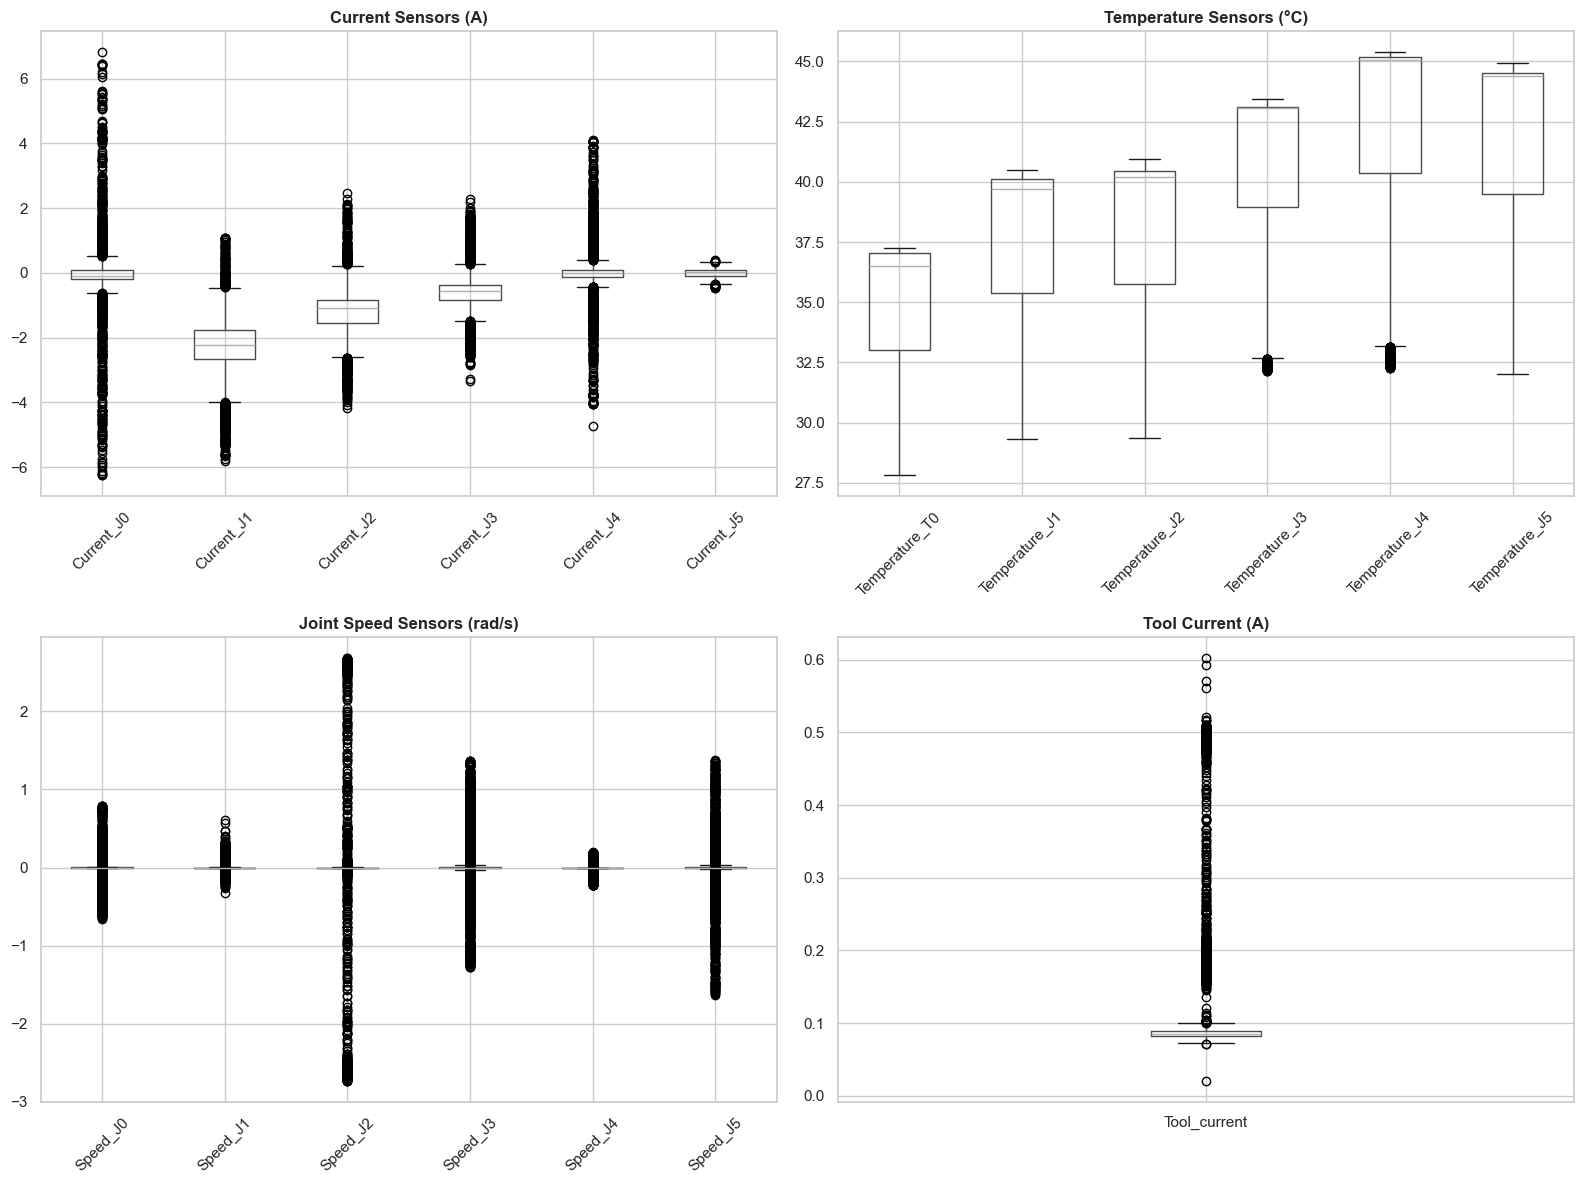

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Current
df.boxplot(column=current_cols, ax=axes[0, 0], rot=45)
axes[0, 0].set_title("Current Sensors (A)", fontweight="bold")

# Temperature
df.boxplot(column=temperature_cols, ax=axes[0, 1], rot=45)
axes[0, 1].set_title("Temperature Sensors (°C)", fontweight="bold")

# Speed
df.boxplot(column=speed_cols, ax=axes[1, 0], rot=45)
axes[1, 0].set_title("Joint Speed Sensors (rad/s)", fontweight="bold")

# Tool current
df.boxplot(column=tool_cols, ax=axes[1, 1])
axes[1, 1].set_title("Tool Current (A)", fontweight="bold")

plt.tight_layout()
fig_path = FIGURES_DIR / "fig02_boxplots.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()

## Correlation heatmap

Correlation matrix across all sensor features (+ target). Saved to `FIGURES_DIR / "fig02_correlation.png"`.

Saved: C:\FDM_Mini_Project\UR3-CobotOps-Fault-Detection\reports\figures\fig02_correlation.png


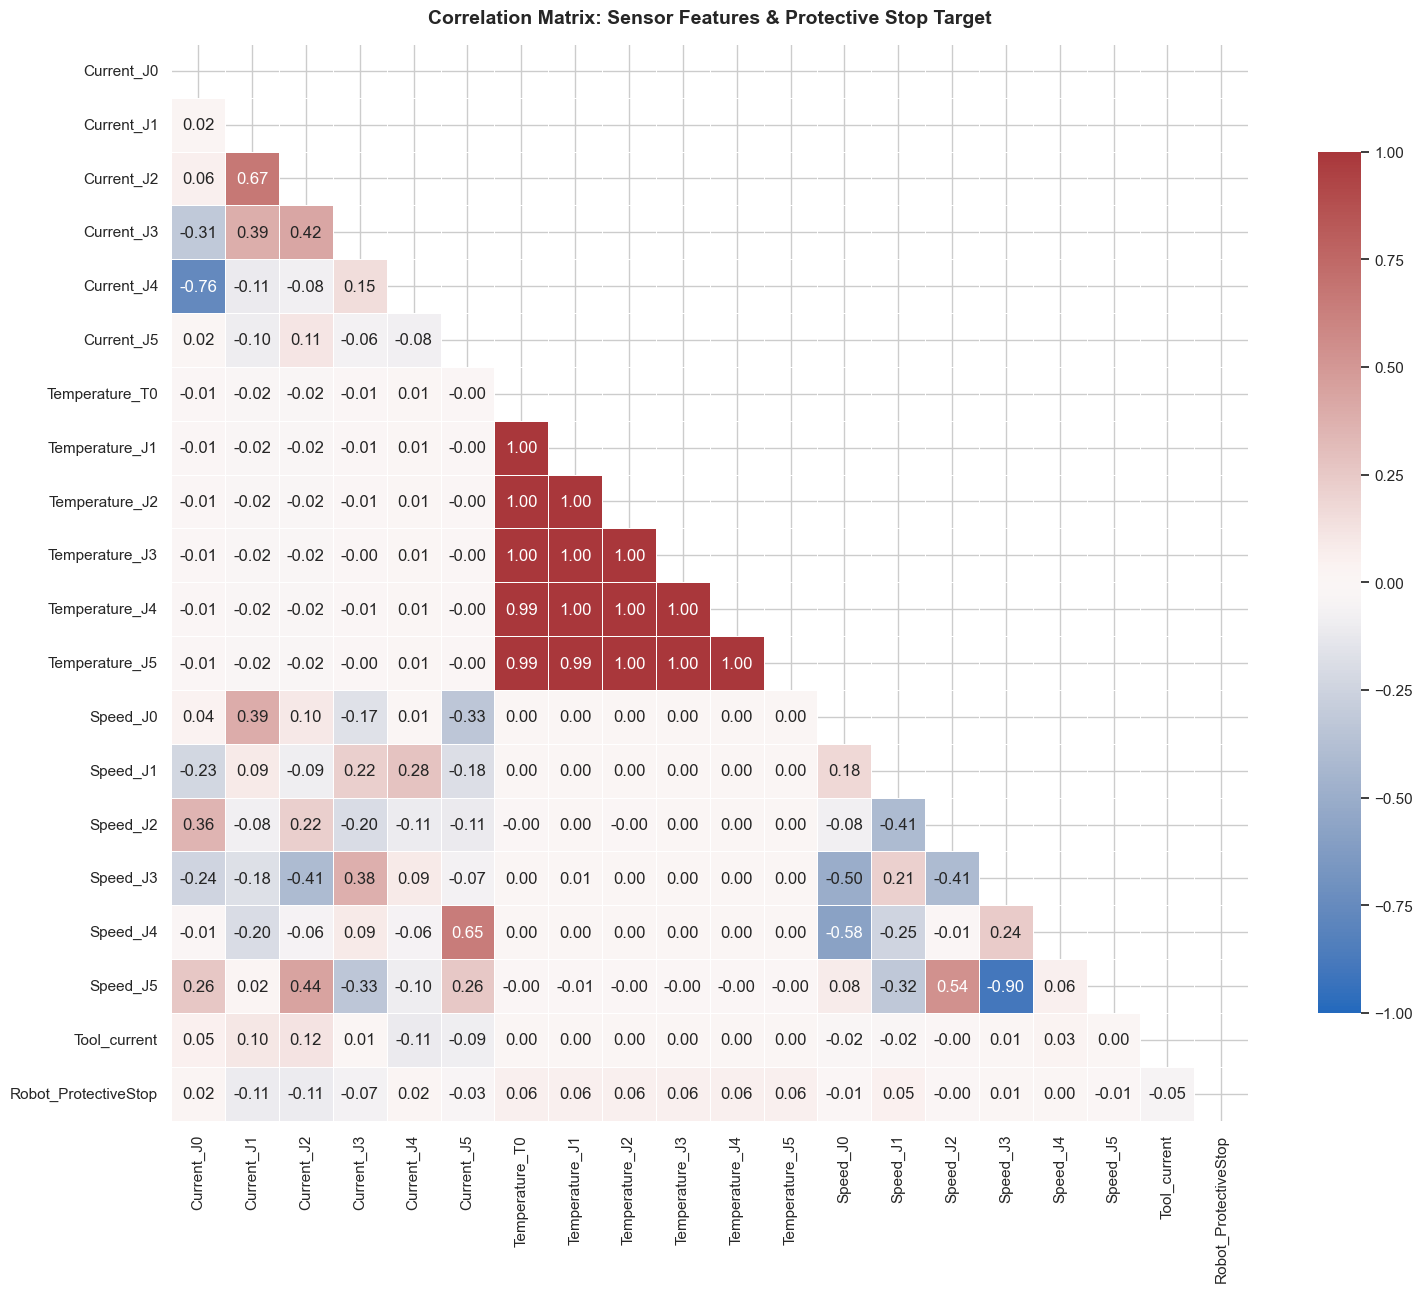

In [8]:
corr_cols = numeric_cols + ["Robot_ProtectiveStop"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix: Sensor Features & Protective Stop Target", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
fig_path = FIGURES_DIR / "fig02_correlation.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()

## grip_lost cross-tab

`pd.crosstab(df["grip_lost"], df["Robot_ProtectiveStop"])`. Plan expects grip_lost overlaps a stop on only 3 rows out of 243 grip-loss rows — confirm it reads as a weak, largely separate signal rather than a strong predictor.

In [9]:
ct = pd.crosstab(
    df["grip_lost"],
    df["Robot_ProtectiveStop"],
    margins=True,
    margins_name="Total"
)
ct_norm = pd.crosstab(
    df["grip_lost"],
    df["Robot_ProtectiveStop"],
    normalize="index"
) * 100

print("Cross-tabulation (Counts):")
display(ct)
print("\nCross-tabulation (Row Percentages %):")
display(ct_norm.round(2))

Cross-tabulation (Counts):


Robot_ProtectiveStop,0.0,1.0,Total
grip_lost,,,
False,6837,275,7112
True,240,3,243
Total,7077,278,7355



Cross-tabulation (Row Percentages %):


Robot_ProtectiveStop,0.0,1.0
grip_lost,,
False,96.13,3.87
True,98.77,1.23


## Class-conditional comparisons

For each sensor family, compare summary stats (median/mean) between stop rows and normal rows — which features separate the classes most clearly? This feeds directly into notebook 03's leakage discussion, so cross-check findings with that notebook (e.g. speed features separating the classes is the leakage signal, not necessarily a usable feature).

In [10]:
medians_by_class = df.groupby("Robot_ProtectiveStop")[numeric_cols].median().T
medians_by_class.columns = ["Normal (0) Median", "Stop (1) Median"]
medians_by_class["Difference"] = medians_by_class["Stop (1) Median"] - medians_by_class["Normal (0) Median"]
medians_by_class["Ratio (Stop/Normal)"] = (medians_by_class["Stop (1) Median"] / medians_by_class["Normal (0) Median"]).round(3)
medians_by_class.sort_values(by="Difference", ascending=False)

,Normal (0) Median,Stop (1) Median,Difference,Ratio (Stop/Normal)
Temperature_T0,36.500000,36.937500,0.437500,1.012
Temperature_J1,39.687500,39.937500,0.250000,1.006
Temperature_J2,40.187500,40.312500,0.125000,1.003
Temperature_J3,43.062500,43.125000,0.062500,1.001
Temperature_J5,44.375000,44.437500,0.062500,1.001
Temperature_J4,45.062500,45.125000,0.062500,1.001
Current_J0,-0.083452,-0.020977,0.062474,0.251
Current_J4,-0.014018,0.018759,0.032777,-1.338
Speed_J0,0.000000,0.000000,0.000000,NaN
Speed_J1,0.000000,0.000000,0.000000,NaN


## Decision log

### Decision 1: Outlier Treatment — Retain Physical Signal
- **Decision:** Retain all extreme sensor values and IQR outliers without clipping or dropping them.
- **Evidence:** IQR outlier analysis indicates up to 8.2% outliers in current and speed channels; however, high current surges and rapid decelerations are genuine physical characteristics of mechanical strain and impending protective stops.
- **Alternative considered:** Winsorizing (clipping at 1st/99th percentile) or removing IQR outliers.
- **Why rejected:** Truncating or dropping these extreme values removes critical anomaly signals needed by classifiers to detect fault states.

### Decision 2: Feature Role of `grip_lost`
- **Decision:** Do not rely on `grip_lost` as a primary indicator for protective stops.
- **Evidence:** `pd.crosstab` reveals that out of 243 total grip loss events, only 3 coincide with a protective stop (1.23% stop rate when grip is lost), showing that grip loss is an operational workpiece issue rather than a driver of protective stops.
- **Alternative considered:** Using `grip_lost` as a strong predictive rule/feature.
- **Why rejected:** Lack of empirical correlation with `Robot_ProtectiveStop`.

### Decision 3: Speed Discrepancy & Leakage Awareness
- **Decision:** Note the dramatic drop in Joint Speeds (e.g., median total speed drops to ~0.002 rad/s during stop rows vs ~0.056 rad/s during normal operations) as post-event manifestation.
- **Evidence:** Class-conditional comparison table shows near-zero velocities during protective stop rows.
- **Alternative considered:** Using instantaneous speed directly as the primary predictor.
- **Why rejected:** Same-row speed is a symptom of a robot that has already halted (consequence leakage), requiring windowed/lagged evaluation in Notebook 03.